In [14]:
import numpy as np
import os


In [15]:
# run_dir = '/Users/akap5486/Projects/groundwater/data/henry_data/one_coupling_scenario/scenario_beta0.200_diffc0.00140/run_000001_hk864.00_por0.350_in2.8510_ghb1.0000'
# run_dir = '/Users/akap5486/Projects/groundwater/data/henry_data/grid_scenarios_20x40/scenarios/scenario_01/run_000001/'
run_dir = os.path.expanduser('~/Projects/groundwater/data/henry_data/grid_scenarios_dynamic_20x40/scenarios/scenario_01/run_000001/')

In [16]:
windows = np.load(run_dir + '/windows.npz')
windows.files

['input_tensor',
 'output_tensor',
 'input_channel_names',
 't_index',
 't_lag_index',
 'time_t',
 'time_t_lag',
 'window_ids',
 'lag',
 'ncol',
 'nlay',
 'total_time',
 'nstp',
 'beta_c',
 'diffc',
 'hk',
 'por',
 'inflow',
 'ghb_head',
 'al',
 'at',
 'cinlet',
 'init_mode',
 'initial_head',
 'initial_concentration']

In [17]:
windows['input_tensor'].shape, windows['output_tensor'].shape

((49, 7, 20, 40), (49, 2, 20, 40))

In [22]:
# Plot conc and head at the first time step of the input tensor
import matplotlib.pyplot as plt
def plot_input_output_at_idx(windows, idx=0):
    input_tensor = windows['input_tensor']
    channel_names = windows['input_channel_names']

    # Decode channel names if stored as bytes
    channel_names = [
        name.decode('utf-8') if isinstance(name, (bytes, np.bytes_)) else str(name)
        for name in channel_names
    ]

    n_channels = input_tensor.shape[1]
    n_cols = min(3, n_channels)
    n_rows = int(np.ceil(n_channels / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 2.2 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ch in range(n_channels):
        if ch == 0:
            cmap = 'Reds'
            axes[ch].set_title(f"{channel_names[ch]}")
        elif ch == 1:
            cmap = 'Blues'
            axes[ch].set_title(f"{channel_names[ch]}")
        else:
            cmap = 'Greens'
            axes[ch].set_title(f"{channel_names[ch]}: \n {input_tensor[idx, ch, :, :].min():.2f}: {input_tensor[idx, ch, :, :].max():.2f}" if ch < len(channel_names) else f'Channel {ch}')

        im = axes[ch].imshow(input_tensor[idx, ch, :, :], origin='upper', cmap=cmap)
        fig.colorbar(im, ax=axes[ch])

    # Hide any unused subplot axes
    for k in range(n_channels, len(axes)):
        axes[k].axis('off')

    plt.tight_layout()
    plt.show()


    fig, ax = plt.subplots(1, 2, figsize=(7, 2))

    im0 = ax[0].imshow(windows['output_tensor'][idx, 0, :, :], origin='upper', cmap='Reds')
    ax[0].set_title('Concentration')
    fig.colorbar(im0, ax=ax[0])

    im1 = ax[1].imshow(windows['output_tensor'][idx, 1, :, :], origin='upper', cmap='Blues')
    ax[1].set_title('Head')
    fig.colorbar(im1, ax=ax[1])

    plt.tight_layout()
    plt.show()

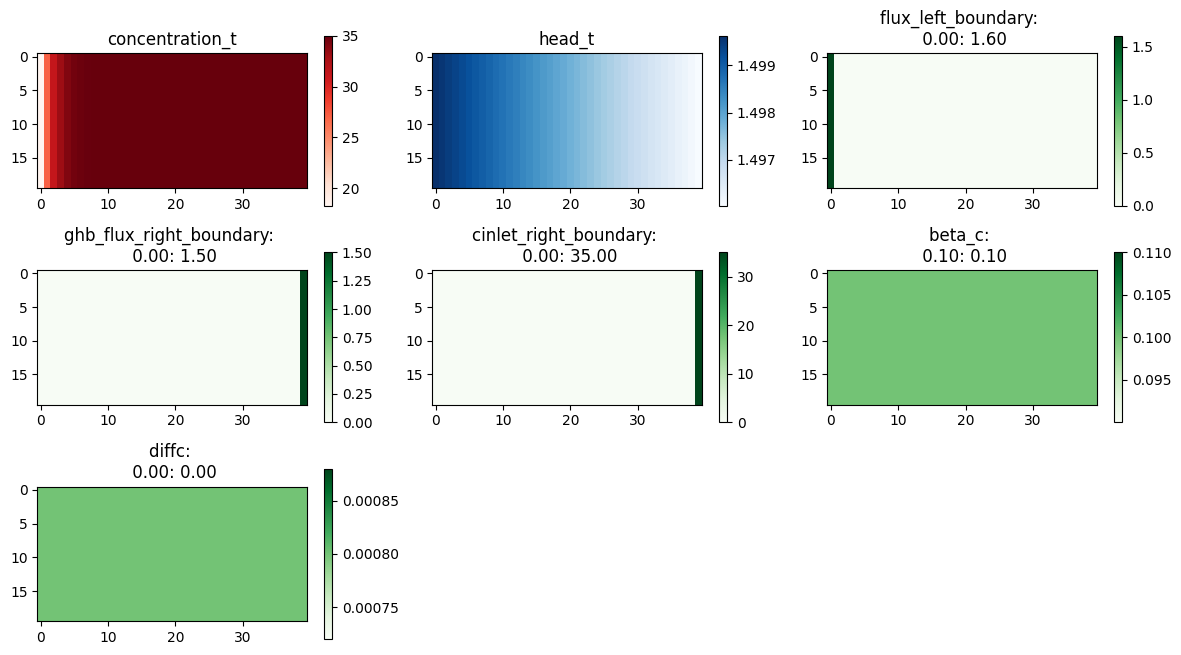

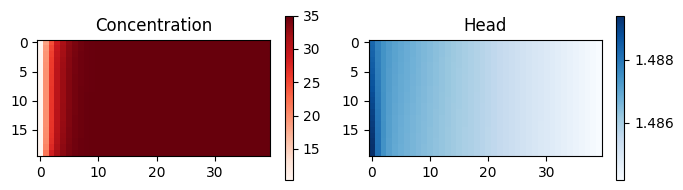

In [23]:
plot_input_output_at_idx(windows, idx=0)

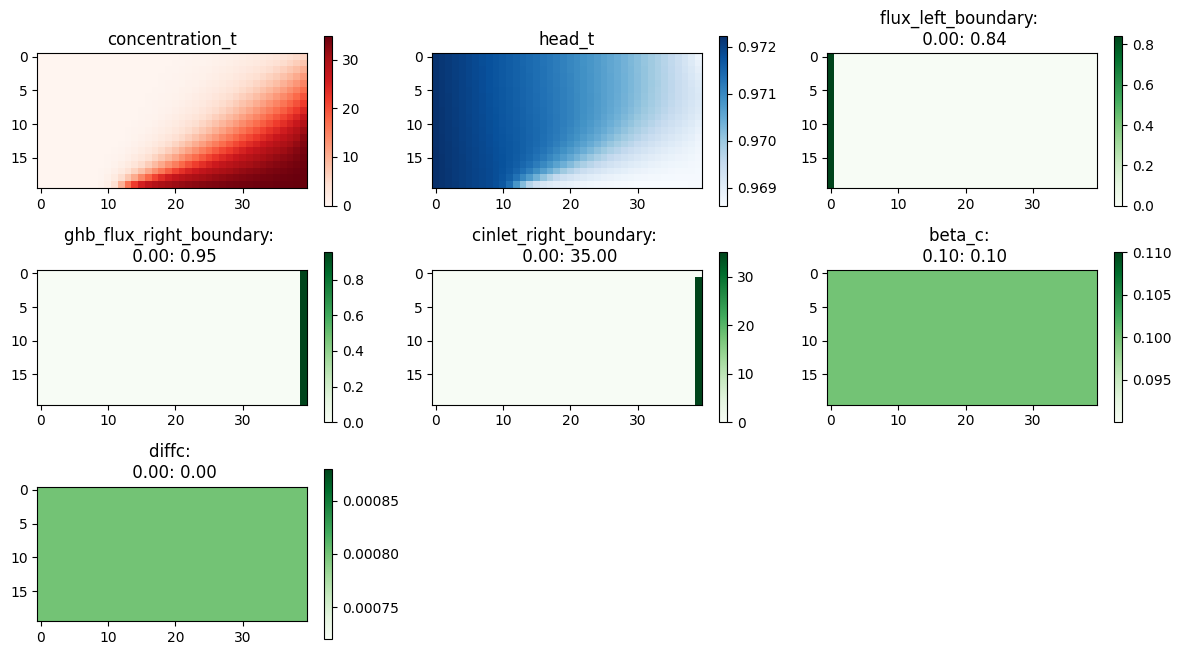

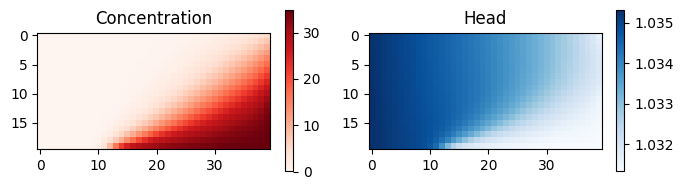

In [25]:
plot_input_output_at_idx(windows, idx=36)

Extracted tidal heads: [1.5        1.49899334 1.49597741 1.49096435 1.48397435 1.47503556
 1.46418397 1.45146327 1.43692469 1.42062677 1.40263513 1.38302222
 1.36186702 1.33925471 1.31527633 1.29002845 1.26361273 1.23613554
 1.20770751 1.17844311 1.14846019 1.11787947 1.08682409 1.0554191
 1.02379096 0.99206702 0.96037502 0.92884258 0.89759667 0.86676309
 0.83646602 0.80682744 0.77796669 0.75       0.72303997 0.69719516
 0.67256963 0.64926256 0.62736778 0.60697345 0.58816171 0.57100829
 0.55558228 0.54194577 0.53015369 0.52025351 0.51228511 0.50628056
 0.50226404 0.50025173 0.50025173 0.50226404 0.50628056 0.51228511
 0.52025351 0.53015369 0.54194577 0.55558228 0.57100829 0.58816171
 0.60697345 0.62736778 0.64926256 0.67256963 0.69719516 0.72303997
 0.75       0.77796669 0.80682744 0.83646602 0.86676309 0.89759667
 0.92884258 0.96037502 0.99206702 1.02379096 1.0554191  1.08682409
 1.11787947 1.14846019 1.17844311 1.20770751 1.23613554 1.26361273
 1.29002845 1.31527633 1.33925471 1.3618

/Users/arpitkapoor/Projects/groundwater/synthetic_problem/henry_mflab/.venv/lib/python3.12/site-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/Users/arpitkapoor/Projects/groundwater/synthetic_problem/henry_mflab/.venv/lib/python3.12/site-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/Users/arpitkapoor/Projects/groundwater/synthetic_problem/henry_mflab/.venv/lib/python3.12/site-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/Users/arpitkapoor/Projects/groundwater/synthetic_problem/henry_mflab/.venv/lib/python3.12/site-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserEleme

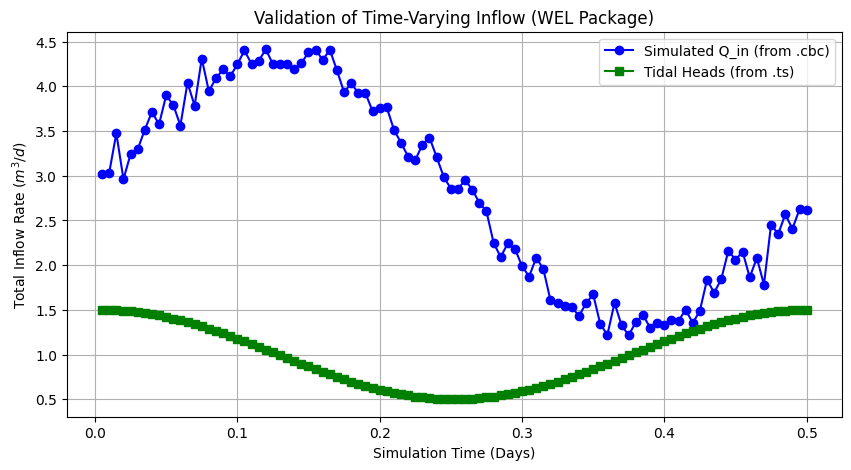

In [45]:
import flopy.utils.binaryfile as bf
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Point to your Cell-by-Cell file (update the filename to match your model name)
cbc_file = os.path.join(run_dir, "gwf.cbc") 

# 2. Open the binary budget file (MODFLOW 6 outputs in double precision)
cbc_obj = bf.CellBudgetFile(cbc_file, precision='double')

# 3. Get the list of all simulation times saved in the file
times = cbc_obj.get_times()

# 4. Extract the WEL package data
# Note: The text parameter usually matches the package name. If 'WEL' returns empty, 
# you can use cbc_obj.get_unique_record_names() to find the exact string.
wel_data = cbc_obj.get_data(text='WEL') 

# 5. Loop through the data to calculate total inflow per time step
actual_qin = []
for step_data in wel_data:
    # step_data is a numpy recarray containing ['node', 'q', etc.]
    # We sum the 'q' (flux) for all cells in the well boundary for this time step
    total_flux = np.sum(step_data['q']) 
    actual_qin.append(total_flux)


tide_heads = []

# Tidal heads time-series
tides_ts = os.path.join(run_dir, 'ghb_ts.ts')

with open(tides_ts, 'r') as f:

    ts_line = None

    for line in f.readlines():
        if line.startswith('BEGIN timeseries'):
            ts_line = True
            continue
        if line.startswith('END timeseries'):
            ts_line = False
            break

        if not ts_line:
            continue
        else:
            parts = line.split()
            if len(parts) >= 2:
                time = float(parts[0])
                head = float(parts[1])
                tide_heads.append(head)

print("Extracted tidal heads:", np.array(tide_heads))


# 6. Plot the extracted fluxes
plt.figure(figsize=(10, 5))
plt.plot(times, actual_qin, marker='o', linestyle='-', color='b', label='Simulated Q_in (from .cbc)')
# plt.plot(times, qghb, marker='s', linestyle='-', color='g', label='Simulated Q_ghb (from .cbc)')
    
plt.plot(times, tide_heads, marker='s', linestyle='-', color='g', label='Tidal Heads (from .ts)')
# Optional: Overlay your intended analytical formula to verify a perfect match
# intended_qin = inflow * (1 + 0.5 * np.sin(2 * np.pi * np.array(times) / total_time))
# plt.plot(times, intended_qin, linestyle='--', color='r', label='Intended Forcing')

plt.title("Validation of Time-Varying Inflow (WEL Package)")
plt.xlabel("Simulation Time (Days)")
plt.ylabel("Total Inflow Rate ($m^3/d$)")
plt.grid(True)
plt.legend()
plt.show()